In [1]:
%load_ext autoreload
%autoreload 2

import parse_data

#sds = [0.05, 0.005, 0.01]
sds = [0.01, 0.02, 0.04]
uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort(), sds.sort()
tskit = True

popsize = 2000

# Ran into some comma issues before
# It's caused by having commas in the HPC, so be sure remove them. But this method also removes all the commas that are in names of the important files.

nes = []
for sd in sds:
    # We are removing any of the commas in the name (if they are there).
    parse_data.remove_commas_recursively(f"/Users/cameronliu/Desktop/Research/Datasets/Current/sd-{sd}-exp-reformatted-tskit")

    # We are calculating the Ne's that are present in each of the sd files. 
    inner_nes = parse_data.get_all_nes(f"/Users/cameronliu/Desktop/Research/Datasets/sd-{sd}-exp-reformatted-tskit", uds, sd, tskit, popsize)
    # This writes all the information of inner_nes into a file. This is for future-proofing, not having to calculate Ne from each file each time - saves lots of computational power
    final_message = parse_data.write_all_nes(inner_nes)

if final_message: print("Successfully parsed data for files {sds}")

Calculating Coalescent Ne: 2009.189778433079 using sd: 0.01, ud: 0.01
Calculating Coalescent Ne: 2024.333939747425 using sd: 0.01, ud: 0.02
Calculating Coalescent Ne: 1985.179959249927 using sd: 0.01, ud: 0.03
Calculating Coalescent Ne: 2006.7210263923737 using sd: 0.01, ud: 0.05
Calculating Coalescent Ne: 1971.030446940875 using sd: 0.01, ud: 0.075
Calculating Coalescent Ne: 1981.3623337154936 using sd: 0.01, ud: 0.1
Calculating Coalescent Ne: 1973.550401477554 using sd: 0.01, ud: 0.2
Calculating Coalescent Ne: 1922.8555469439236 using sd: 0.01, ud: 0.35
Calculating Coalescent Ne: 1909.7338037625825 using sd: 0.01, ud: 0.5
Calculating Coalescent Ne: 1908.201000882852 using sd: 0.01, ud: 0.75
Calculating Coalescent Ne: 1854.1372252125088 using sd: 0.01, ud: 1
Calculating Coalescent Ne: 1791.4242582176753 using sd: 0.01, ud: 1.25
Calculating Coalescent Ne: 1786.5879161715795 using sd: 0.01, ud: 1.5
Calculating Coalescent Ne: 1714.1397812691337 using sd: 0.01, ud: 2
Calculating Coalescen

In [3]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from

import matplotlib.pyplot as plt
import numpy as np    
from scipy import stats
import statistics
import math

# This is my own .py file, with methods that I have created myself.
import parse_data

pop_size = 2000
burnin = 4*pop_size

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort(), sds.sort()
tskit = True

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort()

# These are important to remember
# parse_exp([uds], sd, BURNIN, COMMA)


global_data = []

for sd in sds: 
    #tskit = True if sd == 0.0025 else False
    data, timesteps = parse_data.parse_normal_from_exp(uds, sd, tskit)
    sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)

    global_data.append((sliced_data, sliced_timesteps))

# sliced_data's format = (sd, (ud, f. sel. deaths))
# global_data's format = ([(sd1, (ud1, f. sel. deaths)), (sd2, (ud2, f. sel. deaths)) ... ], [timesteps])


---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.01
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.02
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.03
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.05
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.075
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 

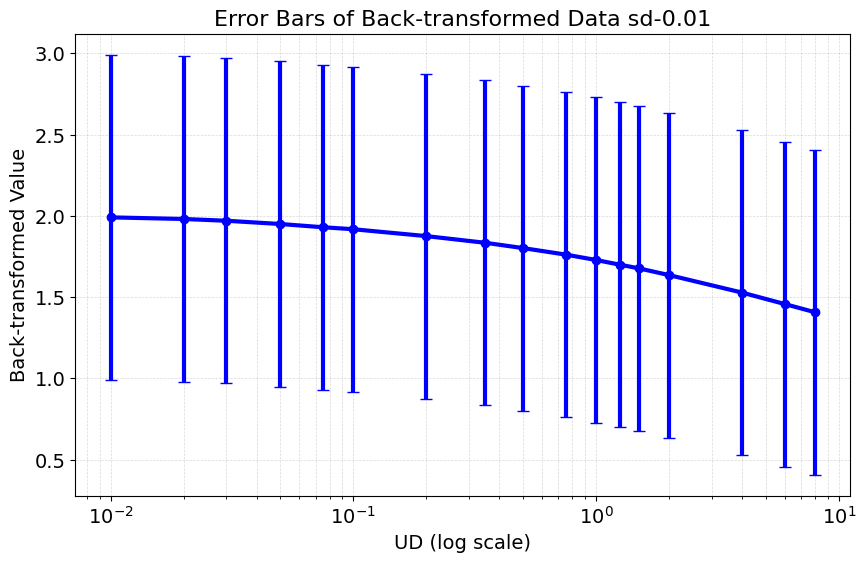

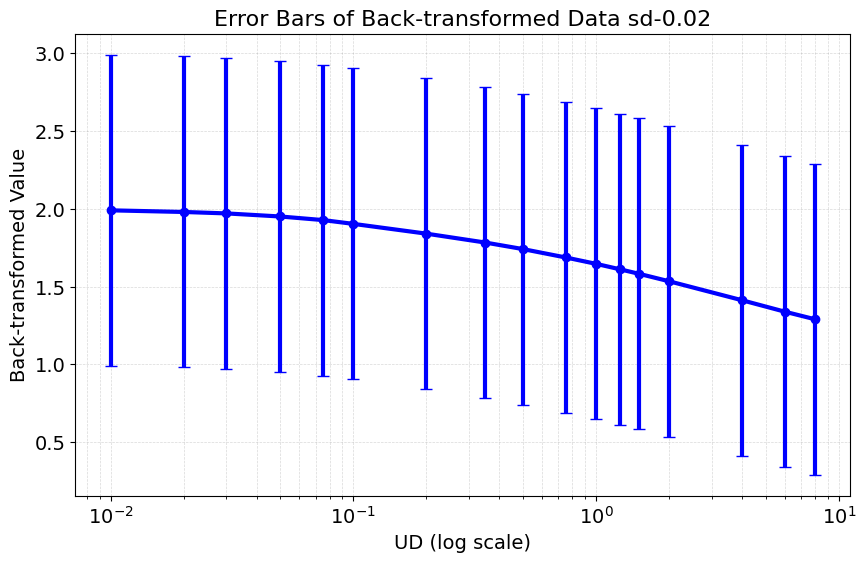

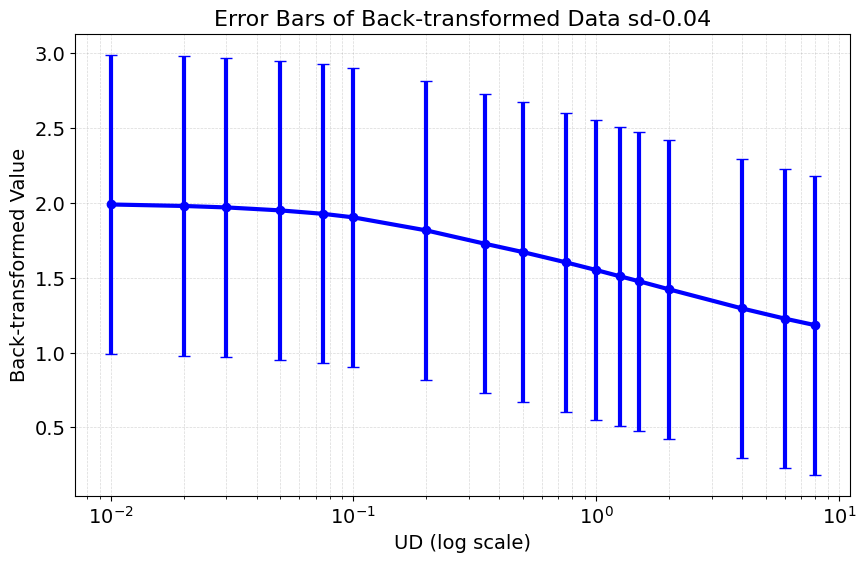

In [ ]:
for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)

    # Get standard errors
    standard_errors = parse_data.get_bounds(transformed_datasets, 12000)

    # Back-transform
    back_transformed_data = parse_data.back_transform_ste(transformed_datasets)

    # back_transformed_data's format is: (ud, mean, sd, (lower_err, upper_err))

    sd_vals = [sd for _, _, sd, _ in back_transformed_data]
    unique_sds = sorted(set(sd_vals))

    # Plot each SD group in its own figure
    for sd in unique_sds:
        plt.figure(figsize=(10, 6))  # bigger figure

        x = [ud for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd]
        y = [mean for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd]
        lowers = [lower for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd]
        uppers = [upper for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd]
    
        yerr = [
            [lower for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd],  # lower errors
            [upper for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd],  # upper errors
        ]


        plt.errorbar(
            x, y, yerr=yerr,
            fmt='o-', capsize=4,
            color="blue"
        )

        plt.xscale("log")  # set x-axis to log scale
        plt.xlabel("UD (log scale)", fontsize=14)
        plt.ylabel("Back-transformed Value", fontsize=14)
        plt.title(f"Error Bars of Back-transformed Data {sd}", fontsize=16)
        plt.grid(True, which="both", alpha=0.3)  # grid works for log scale too
        plt.show()


In [ ]:
for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)

    # back_transformed_data.append((ud, 1 - back_transformed_value, sd, (back_transformed_lower, back_transformed_upper)))
    for (ud, mean, sd, (lower, upper)) in back_transformed_data:
        print(f"UD: {ud}, SD: {sd}, mean: {mean}, ste: {upper} lower: {mean - lower}, upper: {mean + upper}")

    # Get standard errors
    standard_errors = parse_data.get_bounds(transformed_datasets, 12000)

    # Back-transform
    back_transformed_data = parse_data.back_transform_ste(transformed_datasets)

    x = [ud for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd]
    y = [mean for (ud, mean, sd_val, (lower, upper)) in back_transformed_data if sd_val == sd]


    


UD: 0.01, SD: sd-0.01, mean: 0.9903531893018725, ste: 1.0000060174746157 lower: -0.009652828172743155, upper: 1.9903592067764881
UD: 0.02, SD: sd-0.01, mean: 0.9803701958631841, ste: 1.0000139803836368 lower: -0.01964378452045268, upper: 1.9803841762468208
UD: 0.03, SD: sd-0.01, mean: 0.9694607896104611, ste: 1.0000027332205317 lower: -0.030541943610070565, upper: 1.969463522830993
UD: 0.05, SD: sd-0.01, mean: 0.9494906156443421, ste: 1.0000018317534431 lower: -0.05051121610910103, upper: 1.9494924473977853
UD: 0.075, SD: sd-0.01, mean: 0.9295849923506481, ste: 1.0000015558132824 lower: -0.07041656346263436, upper: 1.9295865481639305
UD: 0.1, SD: sd-0.01, mean: 0.9173117172951639, ste: 1.0000118183045033 lower: -0.08270010100933933, upper: 1.9173235355996672
UD: 0.2, SD: sd-0.01, mean: 0.8749920898601512, ste: 1.0000351021565823 lower: -0.1250430122964311, upper: 1.8750271920167334
UD: 0.35, SD: sd-0.01, mean: 0.8338560087112851, ste: 1.000092197977152 lower: -0.16623618926586692, uppe